<a href="https://colab.research.google.com/github/liorzlatin-hub/Deep-Learning-/blob/main/feature_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Vectors & Feature Space

1. Each observation becomes a **feature vector** \(x\) (numbers, categories, words, images… anything).
2. A feature vector lives in a **d-dimensional feature space**.
3. All observations together form a **representation of the system**.
4. **Machine learning** learns a function that maps regions of this space to outcomes (a.k.a. it “colors” the space).

You can run this notebook in **Google Colab** as-is.


In [ ]:
# Cell 1 - Imports + reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.datasets import make_moons, load_digits

np.random.seed(42)


# Cell 2


## 2) “Anything” → Feature vectors  
Here we build a tiny dataset with **numeric + categorical + text** features.

We then transform it into a **single feature matrix** (each row is a feature vector \(x_i\)).


In [ ]:
# Cell 2 - Raw data → engineered feature vectors (numeric + categorical + text)
df = pd.DataFrame({
    "age": [22, 45, 31, 28, 55, 41, 36, 23, 60, 30],
    "country": ["IL", "US", "IL", "UK", "US", "IL", "UK", "IL", "US", "UK"],
    "bio": [
        "loves pizza and sports",
        "enjoys finance and markets",
        "python developer and runner",
        "interested in art and museums",
        "runs marathons and reads books",
        "data science and coffee",
        "music and photography",
        "basketball and gaming",
        "investing and startups",
        "travel and food"
    ],
    # A toy “outcome” we might want to predict (supervised learning)
    "will_buy": [0, 1, 1, 0, 1, 1, 0, 0, 1, 0]
})

df


,age,country,bio,will_buy
0,22,IL,loves pizza and sports,0
1,45,US,enjoys finance and markets,1
2,31,IL,python developer and runner,1
3,28,UK,interested in art and museums,0
4,55,US,runs marathons and reads books,1
5,41,IL,data science and coffee,1
6,36,UK,music and photography,0
7,23,IL,basketball and gaming,0
8,60,US,investing and startups,1
9,30,UK,travel and food,0


In [ ]:
# Cell 3 - Build a feature space with a preprocessing pipeline
X = df[["age", "country", "bio"]]
y = df["will_buy"]

numeric_features = ["age"]
categorical_features = ["country"]
text_feature = "bio"

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("txt", TfidfVectorizer(), text_feature),
    ],
    remainder="drop",
)

X_vec = preprocess.fit_transform(X)

print("Feature matrix type:", type(X_vec))
print("Feature matrix shape (n_observations, d_features):", X_vec.shape)


Feature matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Feature matrix shape (n_observations, d_features): (10, 33)


In [ ]:
X_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 58 stored elements and shape (10, 33)>

In [ ]:
# Cell 3_extra - Feature counts per column + descriptive stats of engineered features

import numpy as np
import pandas as pd

# --- Helper: make dense safely for small matrices ---
def to_dense(M):
    return M.toarray() if hasattr(M, "toarray") else np.asarray(M)

# --- 1) Break the ColumnTransformer output into parts ---
num_transformer = preprocess.named_transformers_["num"]
cat_transformer = preprocess.named_transformers_["cat"]
txt_transformer = preprocess.named_transformers_["txt"]

X_num = num_transformer.transform(X[numeric_features])                          # (n, n_num)
X_cat = cat_transformer.transform(X[categorical_features])                      # (n, n_cat) sparse
X_txt = txt_transformer.transform(X[text_feature].astype(str))                  # (n, n_txt) sparse

# --- 2) Feature names per original column-group ---
num_names = list(numeric_features)

cat_names = list(cat_transformer.get_feature_names_out(categorical_features))
txt_names = list(txt_transformer.get_feature_names_out())

print("=== Feature counts (how many engineered features each input column-group created) ===")
print(f"Numeric ({numeric_features}): {len(num_names)} feature(s)")
print(f"Categorical ({categorical_features}): {len(cat_names)} one-hot feature(s)")
print(f"Text ('{text_feature}'): {len(txt_names)} TF-IDF feature(s)")
print(f"\nTotal engineered features: {X_vec.shape[1]} (should equal {len(num_names)+len(cat_names)+len(txt_names)})")

# --- 3) Sparsity / nnz explanation (where the '58 stored elements' comes from) ---
print("\n=== Sparsity summary ===")
print("X_vec shape:", X_vec.shape)
print("X_vec non-zeros (nnz):", X_vec.nnz)
print("X_vec density:", X_vec.nnz / (X_vec.shape[0] * X_vec.shape[1]))

# Non-zeros by component
nnz_num = np.count_nonzero(to_dense(X_num))
nnz_cat = X_cat.nnz if hasattr(X_cat, "nnz") else np.count_nonzero(X_cat)
nnz_txt = X_txt.nnz if hasattr(X_txt, "nnz") else np.count_nonzero(X_txt)
print("\nNon-zeros by component:")
print("  numeric nnz:", nnz_num)
print("  one-hot  nnz:", nnz_cat)
print("  tf-idf   nnz:", nnz_txt)
print("  total    nnz:", nnz_num + nnz_cat + nnz_txt)

# Non-zeros per row (useful intuition)
row_nnz = np.diff(X_vec.indptr)  # CSR trick: nnz per row
print("\nNon-zeros per observation (row):", row_nnz.tolist())
print("Avg nnz per row:", row_nnz.mean())

# --- 4) Descriptive statistics ---
print("\n=== Descriptive stats: ORIGINAL numeric columns (raw) ===")
display(df[numeric_features].describe())

# Numeric after scaling
df_num_scaled = pd.DataFrame(to_dense(X_num), columns=[f"{c} (scaled)" for c in num_names])
print("\n=== Descriptive stats: numeric after scaling ===")
display(df_num_scaled.describe())

# One-hot stats (these are 0/1 columns)
df_cat = pd.DataFrame(to_dense(X_cat), columns=cat_names)
print("\n=== Descriptive stats: one-hot encoded categorical features ===")
display(df_cat.describe())

# TF-IDF stats: can be wide; show compact summaries + top terms
X_txt_dense = to_dense(X_txt)
df_txt = pd.DataFrame(X_txt_dense, columns=txt_names)

print("\n=== TF-IDF summary (compact) ===")
txt_nonzero_per_row = (X_txt_dense > 0).sum(axis=1)
print("TF-IDF features:", df_txt.shape[1])
print("Avg non-zero TF-IDF terms per row:", txt_nonzero_per_row.mean())
print("Min/Max non-zero TF-IDF terms per row:", txt_nonzero_per_row.min(), "/", txt_nonzero_per_row.max())

# Show top terms by average TF-IDF weight
top_by_mean = df_txt.mean(axis=0).sort_values(ascending=False).head(15)
print("\nTop TF-IDF terms by average weight (top 15):")
display(top_by_mean.to_frame("mean_tfidf"))

# Show top terms by document frequency (how many rows contain the term)
doc_freq = (df_txt > 0).sum(axis=0).sort_values(ascending=False).head(15)
print("\nTop TF-IDF terms by document frequency (top 15):")
display(doc_freq.to_frame("doc_freq"))


=== Feature counts (how many engineered features each input column-group created) ===
Numeric (['age']): 1 feature(s)
Categorical (['country']): 3 one-hot feature(s)
Text ('bio'): 29 TF-IDF feature(s)

Total engineered features: 33 (should equal 33)

=== Sparsity summary ===
X_vec shape: (10, 33)
X_vec non-zeros (nnz): 58
X_vec density: 0.17575757575757575

Non-zeros by component:
  numeric nnz: 10
  one-hot  nnz: 10
  tf-idf   nnz: 38
  total    nnz: 58

Non-zeros per observation (row): [6, 6, 6, 7, 7, 6, 5, 5, 5, 5]
Avg nnz per row: 5.8

=== Descriptive stats: ORIGINAL numeric columns (raw) ===


,age
count,10.000000
mean,37.100000
std,12.999573
min,22.000000
25%,28.500000
50%,33.500000
75%,44.000000
max,60.000000



=== Descriptive stats: numeric after scaling ===


,age (scaled)
count,1.000000e+01
mean,-9.992007e-17
std,1.054093e+00
min,-1.224409e+00
25%,-6.973457e-01
50%,-2.919121e-01
75%,5.594983e-01
max,1.856886e+00



=== Descriptive stats: one-hot encoded categorical features ===


,country_IL,country_UK,country_US
count,10.000000,10.000000,10.000000
mean,0.400000,0.300000,0.300000
std,0.516398,0.483046,0.483046
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.750000,0.750000
max,1.000000,1.000000,1.000000



=== TF-IDF summary (compact) ===
TF-IDF features: 29
Avg non-zero TF-IDF terms per row: 3.8
Min/Max non-zero TF-IDF terms per row: 3 / 5

Top TF-IDF terms by average weight (top 15):


,mean_tfidf
and,0.221031
basketball,0.068411
gaming,0.068411
food,0.068411
investing,0.068411
startups,0.068411
photography,0.068411
music,0.068411
travel,0.068411
finance,0.056463



Top TF-IDF terms by document frequency (top 15):


,doc_freq
and,10
art,1
basketball,1
books,1
coffee,1
data,1
developer,1
enjoys,1
finance,1
food,1


In [ ]:
# Cell 4 - Peek inside one feature vector (sparse, non-zero features)
# Many real feature spaces are high-dimensional and sparse.
# Let's inspect the non-zero entries of one observation's vector.

row_idx = 0
row = X_vec[row_idx]

# Make it 1D
row = row.toarray().ravel() if hasattr(row, "toarray") else np.asarray(row).ravel()
nonzero = np.where(row != 0)[0]

print("Observation:", X.iloc[row_idx].to_dict())
print(f"Non-zero feature indices (count={len(nonzero)}):", nonzero[:20], "..." if len(nonzero) > 20 else "")
print("Non-zero values (first few):", row[nonzero[:10]])


Observation: {'age': 22, 'country': 'IL', 'bio': 'loves pizza and sports'}
Non-zero feature indices (count=6): [ 0  1  4 18 24 30] 
Non-zero values (first few): [-1.22440929  1.          0.20875514  0.56463005  0.56463005  0.56463005]


In [ ]:
vocab = txt_transformer.vocabulary_
print("TF-IDF features:", len(vocab))
print("Example tokens:", list(vocab.keys())[:20])

TF-IDF features: 29
Example tokens: ['loves', 'pizza', 'and', 'sports', 'enjoys', 'finance', 'markets', 'python', 'developer', 'runner', 'interested', 'in', 'art', 'museums', 'runs', 'marathons', 'reads', 'books', 'data', 'science']


# Cell 5


## 3) Feature space visualization (PCA)  
The feature space is **d-dimensional**. We can project it down to 2D with PCA to *see* it.

This illustrates the idea: **“all vectors together represent the system.”**


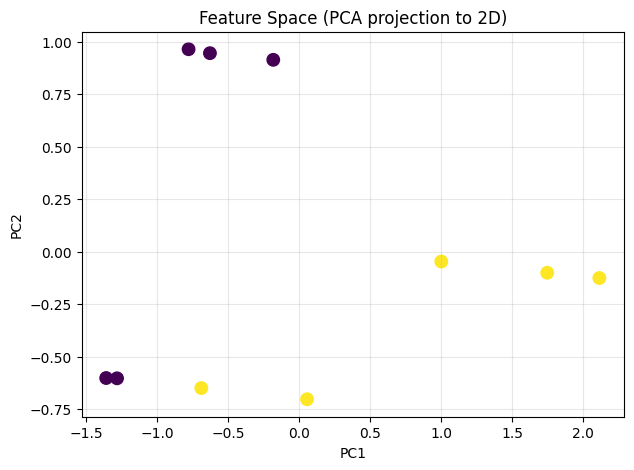

Explained variance ratio: [0.53764099 0.17206081]


In [ ]:
# Cell 5 - Project high-dimensional vectors to 2D and visualize
# PCA requires dense input. Our matrix is small, so converting is fine.
X_dense = X_vec.toarray() if hasattr(X_vec, "toarray") else np.asarray(X_vec)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_dense)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=80)
plt.title("Feature Space (PCA projection to 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


# Cell 6


## 4) Training a model = “coloring” the feature space  
In supervised learning, we train a function \(f(x)\) that maps a feature vector \(x\) to an outcome \(y\).

To make the “coloring” idea very visual, we use a simple 2D dataset and plot the model’s decision regions.


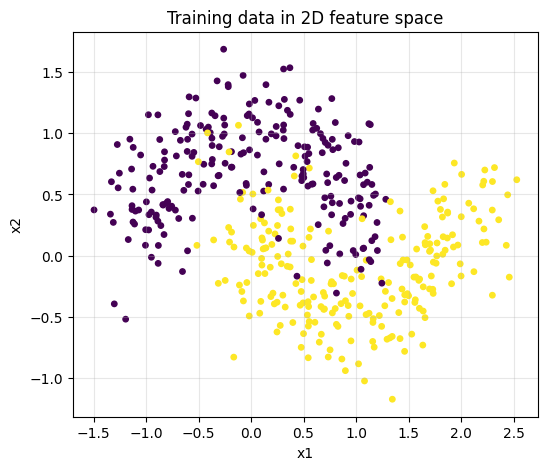

In [ ]:
# Cell 6 - Create a simple 2D dataset where we can visualize the decision boundary
X2, y2 = make_moons(n_samples=600, noise=0.25, random_state=42)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42, stratify=y2
)

plt.figure(figsize=(6, 5))
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, s=15)
plt.title("Training data in 2D feature space")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()


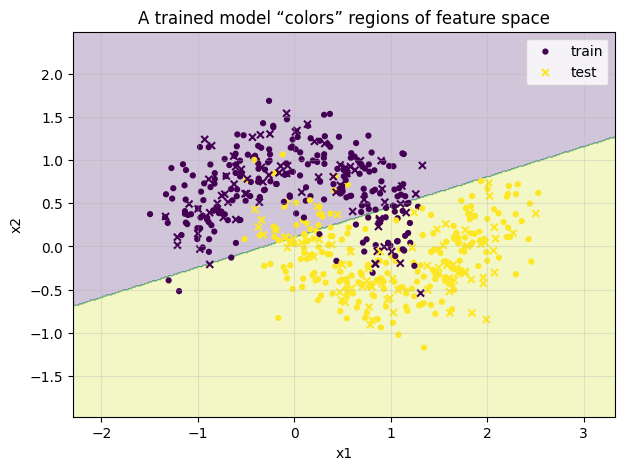

Train accuracy: 0.8622222222222222
Test  accuracy: 0.86


In [ ]:
# Cell 7 - Train a classifier and visualize the “colored” feature space
clf = LogisticRegression(max_iter=500)
clf.fit(X2_train, y2_train)

# Create a grid over the feature space and predict on each point
x_min, x_max = X2[:, 0].min() - 0.8, X2[:, 0].max() + 0.8
y_min, y_max = X2[:, 1].min() - 0.8, X2[:, 1].max() + 0.8
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
pred_grid = clf.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, pred_grid, alpha=0.25)
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train, s=12, label="train")
plt.scatter(X2_test[:, 0], X2_test[:, 1], c=y2_test, s=25, marker="x", label="test")
plt.title("A trained model “colors” regions of feature space")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Train accuracy:", clf.score(X2_train, y2_train))
print("Test  accuracy:", clf.score(X2_test, y2_test))


              precision    recall  f1-score   support

           0       0.88      0.84      0.86        75
           1       0.85      0.88      0.86        75

    accuracy                           0.86       150
   macro avg       0.86      0.86      0.86       150
weighted avg       0.86      0.86      0.86       150



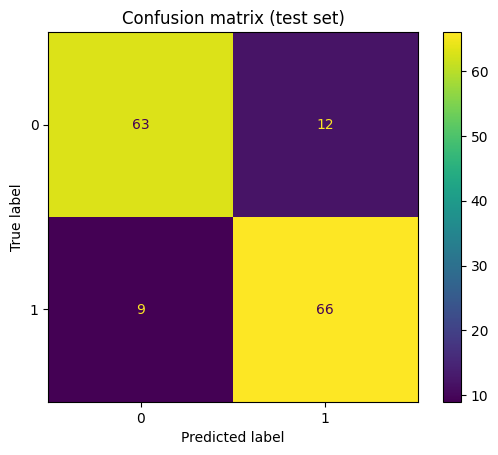

In [ ]:
# Cell 8 - Evaluate predictions (what the model learned about the system)
y2_pred = clf.predict(X2_test)
print(classification_report(y2_test, y2_pred))

ConfusionMatrixDisplay.from_predictions(y2_test, y2_pred)
plt.title("Confusion matrix (test set)")
plt.show()


# Cell 9


## 5) Feature vectors can be images  
An image can be turned into a feature vector by flattening its pixels (or using a CNN embedding in modern systems).

We’ll use the classic **digits** dataset (8×8 images) to show:
- each image → a 64-dimensional feature vector
- all vectors together → a “system” in feature space
- PCA can visualize structure in 2D


X_img shape: (1797, 64)
Example feature vector length (d): 64


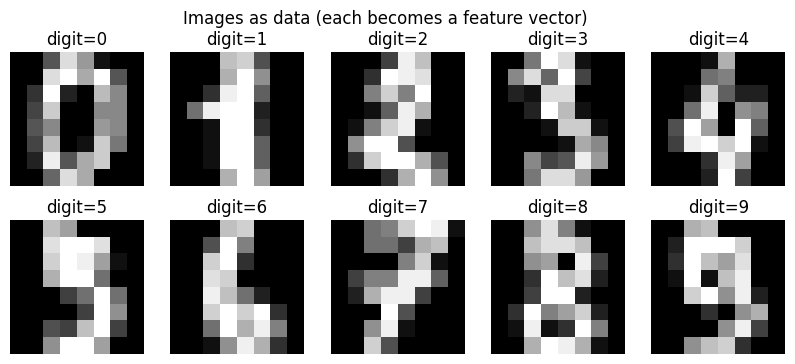

In [ ]:
# Cell 9 - Load images → flatten into feature vectors
digits = load_digits()
X_img = digits.data          # shape: (n_samples, 64)
y_img = digits.target        # digit labels 0..9
images = digits.images       # shape: (n_samples, 8, 8)

print("X_img shape:", X_img.shape)
print("Example feature vector length (d):", X_img.shape[1])

# Show a few images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"digit={y_img[idx]}")
    ax.axis("off")
plt.suptitle("Images as data (each becomes a feature vector)")
plt.show()


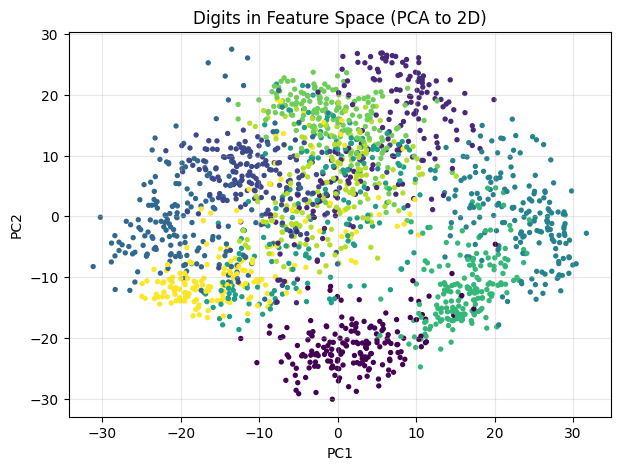

Explained variance ratio: [0.14890594 0.13618771]


In [ ]:
# Cell 10 - PCA projection of image feature vectors to 2D
pca_img = PCA(n_components=2, random_state=42)
X_img_2d = pca_img.fit_transform(X_img)

plt.figure(figsize=(7, 5))
plt.scatter(X_img_2d[:, 0], X_img_2d[:, 1], c=y_img, s=8)
plt.title("Digits in Feature Space (PCA to 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

print("Explained variance ratio:", pca_img.explained_variance_ratio_)


# Cell 11

## 6) Wrap-up

- **Observation → feature vector:** $x_i = [x_1, x_2, \ldots, x_d]$ (numbers, categories, text, images, etc.).
- **Feature vectors form a feature space:** each $x_i$ is a point in $\mathbb{R}^d$ (or a sparse space).
- **All points represent the system:** the dataset is a cloud / manifold / structure in that space.
- **ML training learns a function:** a mapping $f(x)$ that “colors” regions of that space with outcomes.

**Your job as the ML engineer:**
- **A)** Build a good representation (feature engineering / embeddings).
- **B)** Train a model that maps representation → outcomes (and validate/monitor it).
